
RQ5 TABLE:

        Model  Accuracy
0  Default RF  0.824333
1    Tuned RF  0.823667

Best Parameters:
 {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


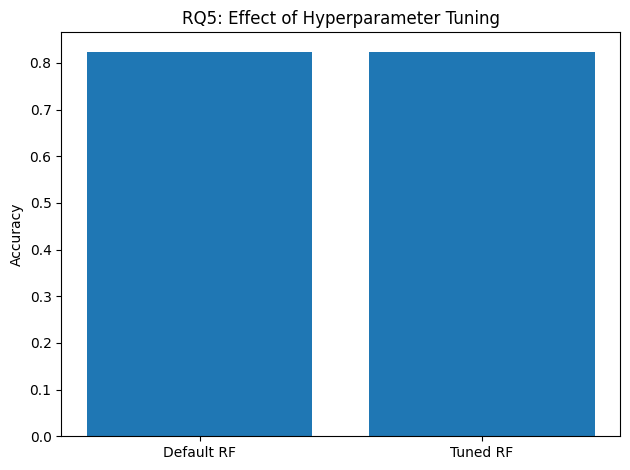


Files saved in: C:\Users\vishwa\kidney disease prediction/outputs/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# =========================
# 0. OUTPUT FOLDER
# =========================
os.makedirs("outputs", exist_ok=True)


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("kidney_disease_balanced.csv")
df.replace('?', np.nan, inplace=True)


# =========================
# 2. SPLIT TARGET
# =========================
y = df["Target"]
X = df.drop("Target", axis=1)


# =========================
# 3. DETECT COLUMNS
# =========================
cat_cols = X.select_dtypes(include=['str']).columns

if len(cat_cols) == 0:
    cat_cols = X.select_dtypes(include=['str']).columns

num_cols = X.columns.difference(cat_cols)


# =========================
# 4. PREPROCESSING
# =========================
# Impute
X[num_cols] = SimpleImputer(strategy='mean').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

# Encode
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Encode target
y = LabelEncoder().fit_transform(y)

# Scale
X = StandardScaler().fit_transform(X)


# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 6. DEFAULT MODEL
# =========================
default_model = RandomForestClassifier()
default_model.fit(X_train, y_train)

y_pred_default = default_model.predict(X_test)
default_acc = accuracy_score(y_test, y_pred_default)


# =========================
# 7. HYPERPARAMETER TUNING
# =========================
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)


# =========================
# 8. CREATE TABLE
# =========================
df_out = pd.DataFrame({
    "Model": ["Default RF", "Tuned RF"],
    "Accuracy": [default_acc, tuned_acc]
})

df_out.to_csv("outputs/RQ5_table.csv", index=False)

print("\nRQ5 TABLE:\n")
print(df_out)

print("\nBest Parameters:\n", grid.best_params_)


# =========================
# 9. CREATE FIGURE
# =========================
plt.figure()

plt.bar(df_out["Model"], df_out["Accuracy"])

plt.title("RQ5: Effect of Hyperparameter Tuning")
plt.ylabel("Accuracy")

plt.tight_layout()

plt.savefig("outputs/RQ5_figure.pdf")

plt.show()


# =========================
# 10. CONFIRM SAVE
# =========================
print("\nFiles saved in:", os.getcwd() + "/outputs/")